# Differentially Private Gaussian Naive Bayes - Lung Cancer Dataset

Trains a DP Gaussian NB (diffprivlib) on the Lung Cancer dataset (50k samples, 23 features, 3-class).

ε ∈ {0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0}, 30 runs each.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from diffprivlib.models import GaussianNB as DPGaussianNB
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score,
)
import pickle, json, os
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']
bounds = data['bounds']
n_classes = data.get('n_classes', 3)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Classes: {n_classes}")

Training set: (40000, 23)
Test set: (10000, 23)
Classes: 3


## 3. Load Baseline Results

In [3]:
try:
    baseline_df = pd.read_csv('output/baseline_results.csv')
    baseline_accuracy = baseline_df['accuracy'].values[0]
    baseline_f1 = baseline_df['f1_score'].values[0]
    print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"Baseline F1-Score: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: Run STD_GNB.ipynb first.")
    baseline_accuracy = None
    baseline_f1 = None

Baseline Accuracy: 0.8931
Baseline F1-Score: 0.8935


## 4. Quick Demo at ε=1.0 (30 Runs)

In [4]:
epsilon = 1.0
N_RUNS = 30
detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []

print(f"Training DP GaussianNB {N_RUNS} times with epsilon={epsilon}...")
print('=' * 60)

detail_extra = ExtraMetrics()
for run in range(N_RUNS):
    seed = run * 10 + 42
    np.random.seed(seed)
    dp_gnb = DPGaussianNB(epsilon=epsilon, bounds=bounds)
    _t0 = time.perf_counter()
    dp_gnb.fit(X_train, y_train)
    train_time = time.perf_counter() - _t0
    y_pred = dp_gnb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    detail_extra.add(y_test, y_pred, model=dp_gnb, X=X_test, train_time=train_time)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    detail_accuracies.append(acc)
    detail_f1s.append(f1)
    detail_precisions.append(prec)
    detail_recalls.append(rec)
    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")

print('=' * 60)
print(f"\nMean Accuracy: {np.mean(detail_accuracies):.4f} +/- {np.std(detail_accuracies):.4f}")
print(f"Mean F1-Score: {np.mean(detail_f1s):.4f} +/- {np.std(detail_f1s):.4f}")

print("Added metrics over the detail runs:")
print(detail_extra.describe())

Training DP GaussianNB 30 times with epsilon=1.0...
  Run  1/30 | Acc: 0.9022 | F1: 0.9023 | Prec: 0.9090 | Rec: 0.9022
  Run  2/30 | Acc: 0.9236 | F1: 0.9240 | Prec: 0.9264 | Rec: 0.9236
  Run  3/30 | Acc: 0.9037 | F1: 0.9042 | Prec: 0.9081 | Rec: 0.9037
  Run  4/30 | Acc: 0.8931 | F1: 0.8935 | Prec: 0.8988 | Rec: 0.8931
  Run  5/30 | Acc: 0.9151 | F1: 0.9156 | Prec: 0.9185 | Rec: 0.9151
  Run  6/30 | Acc: 0.9041 | F1: 0.9044 | Prec: 0.9096 | Rec: 0.9041
  Run  7/30 | Acc: 0.9237 | F1: 0.9240 | Prec: 0.9254 | Rec: 0.9237
  Run  8/30 | Acc: 0.8931 | F1: 0.8935 | Prec: 0.8988 | Rec: 0.8931
  Run  9/30 | Acc: 0.8939 | F1: 0.8943 | Prec: 0.8997 | Rec: 0.8939
  Run 10/30 | Acc: 0.9022 | F1: 0.9023 | Prec: 0.9090 | Rec: 0.9022
  Run 11/30 | Acc: 0.8931 | F1: 0.8934 | Prec: 0.8972 | Rec: 0.8931


  Run 12/30 | Acc: 0.9062 | F1: 0.9065 | Prec: 0.9114 | Rec: 0.9062


  Run 13/30 | Acc: 0.8514 | F1: 0.8541 | Prec: 0.8712 | Rec: 0.8514
  Run 14/30 | Acc: 0.8931 | F1: 0.8935 | Prec: 0.8988 | Rec: 0.8931
  Run 15/30 | Acc: 0.9023 | F1: 0.9011 | Prec: 0.9087 | Rec: 0.9023
  Run 16/30 | Acc: 0.9228 | F1: 0.9221 | Prec: 0.9287 | Rec: 0.9228
  Run 17/30 | Acc: 0.8931 | F1: 0.8935 | Prec: 0.8988 | Rec: 0.8931
  Run 18/30 | Acc: 0.8952 | F1: 0.8956 | Prec: 0.9008 | Rec: 0.8952
  Run 19/30 | Acc: 0.8931 | F1: 0.8934 | Prec: 0.8972 | Rec: 0.8931
  Run 20/30 | Acc: 0.8952 | F1: 0.8956 | Prec: 0.9006 | Rec: 0.8952
  Run 21/30 | Acc: 0.8839 | F1: 0.8853 | Prec: 0.8886 | Rec: 0.8839
  Run 22/30 | Acc: 0.9037 | F1: 0.9042 | Prec: 0.9071 | Rec: 0.9037
  Run 23/30 | Acc: 0.8939 | F1: 0.8943 | Prec: 0.8997 | Rec: 0.8939
  Run 24/30 | Acc: 0.9022 | F1: 0.9023 | Prec: 0.9090 | Rec: 0.9022


  Run 25/30 | Acc: 0.8931 | F1: 0.8934 | Prec: 0.8972 | Rec: 0.8931


  Run 26/30 | Acc: 0.9132 | F1: 0.9132 | Prec: 0.9205 | Rec: 0.9132
  Run 27/30 | Acc: 0.8931 | F1: 0.8935 | Prec: 0.8988 | Rec: 0.8931
  Run 28/30 | Acc: 0.9037 | F1: 0.9042 | Prec: 0.9071 | Rec: 0.9037
  Run 29/30 | Acc: 0.8818 | F1: 0.8823 | Prec: 0.8885 | Rec: 0.8818
  Run 30/30 | Acc: 0.9072 | F1: 0.9077 | Prec: 0.9113 | Rec: 0.9072

Mean Accuracy: 0.8992 +/- 0.0137
Mean F1-Score: 0.8996 +/- 0.0133
Added metrics over the detail runs:
  Balanced Acc:   0.8977 ± 0.0131
  AUROC:          0.9789 ± 0.0083
  Train Time (s): 0.0099 ± 0.0003


## 5. Full Sweep Across All Epsilon Values

In [5]:
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]
N_RUNS = 30

results = {
    'epsilon': [], 'accuracy_mean': [], 'accuracy_std': [],
    'f1_score_mean': [], 'f1_score_std': [],
    'precision_mean': [], 'precision_std': [],
    'recall_mean': [], 'recall_std': [],
}

all_results = {
    'model_type': 'Differentially Private Gaussian Naive Bayes',
    'dataset': 'Lung Cancer',
    'n_samples': X_train.shape[0] + X_test.shape[0],
    'n_features': X_train.shape[1],
    'n_classes': n_classes,
    'n_runs_per_epsilon': N_RUNS,
    'epsilon_results': {}
}

print(f"Training DP GNB with {N_RUNS} runs per epsilon...")
print('=' * 80)

for eps in epsilon_values:
    run_accs, run_f1s, run_precs, run_recs, run_cms = [], [], [], [], []

    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42
        np.random.seed(seed)
        dp_gnb = DPGaussianNB(epsilon=eps, bounds=bounds)
        _t0 = time.perf_counter()
        dp_gnb.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        y_pred = dp_gnb.predict(X_test)
        run_accs.append(accuracy_score(y_test, y_pred))
        extra.add(y_test, y_pred, model=dp_gnb, X=X_test, train_time=train_time)
        run_f1s.append(f1_score(y_test, y_pred, average='weighted', zero_division=0))
        run_precs.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        run_recs.append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
        run_cms.append(confusion_matrix(y_test, y_pred).tolist())
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(dp_gnb, f'output/model/dp_gnb_model_eps_{eps}.pkl')

    acc_mean, acc_std = np.mean(run_accs), np.std(run_accs)
    f1_mean, f1_std = np.mean(run_f1s), np.std(run_f1s)
    prec_mean, prec_std = np.mean(run_precs), np.std(run_precs)
    rec_mean, rec_std = np.mean(run_recs), np.std(run_recs)

    results['epsilon'].append(eps)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(prec_mean)
    results['precision_std'].append(prec_std)
    results['recall_mean'].append(rec_mean)
    results['recall_std'].append(rec_std)

    all_results['epsilon_results'][str(eps)] = {
        'epsilon': float(eps), 'n_runs': N_RUNS,
        'accuracy_mean': acc_mean, 'accuracy_std': acc_std,
        'f1_mean': f1_mean, 'f1_std': f1_std,
        'precision_mean': prec_mean, 'precision_std': prec_std,
        'recall_mean': rec_mean, 'recall_std': rec_std,
        'per_run_accuracies': run_accs, 'per_run_f1s': run_f1s,
        'per_run_confusion_matrices': run_cms,
    }
    all_results['epsilon_results'][str(eps)].update(extra.summary())
    all_results['epsilon_results'][str(eps)].update(extra.per_run())

    print(f"eps={eps:5.2f} | Acc: {acc_mean:.4f}+/-{acc_std:.4f} | F1: {f1_mean:.4f}+/-{f1_std:.4f}")

print('=' * 80)
print('Training complete!')

Training DP GNB with 30 runs per epsilon...


Model successfully exported to output/model/dp_gnb_model_eps_0.1.pkl


eps= 0.10 | Acc: 0.7865+/-0.0992 | F1: 0.7774+/-0.1046
Model successfully exported to output/model/dp_gnb_model_eps_0.2.pkl


eps= 0.20 | Acc: 0.8211+/-0.0790 | F1: 0.8139+/-0.0888
Model successfully exported to output/model/dp_gnb_model_eps_0.4.pkl


eps= 0.40 | Acc: 0.8728+/-0.0670 | F1: 0.8695+/-0.0768
Model successfully exported to output/model/dp_gnb_model_eps_0.6.pkl


...

eps= 2.00 | Acc: 0.8937+/-0.0054 | F1: 0.8941+/-0.0053
Model successfully exported to output/model/dp_gnb_model_eps_4.0.pkl


eps= 4.00 | Acc: 0.8942+/-0.0043 | F1: 0.8946+/-0.0043
Model successfully exported to output/model/dp_gnb_model_eps_6.0.pkl


eps= 6.00 | Acc: 0.8931+/-0.0000 | F1: 0.8935+/-0.0000
Model successfully exported to output/model/dp_gnb_model_eps_8.0.pkl


eps= 8.00 | Acc: 0.8935+/-0.0019 | F1: 0.8939+/-0.0019
Model successfully exported to output/model/dp_gnb_model_eps_10.0.pkl


eps=10.00 | Acc: 0.8931+/-0.0000 | F1: 0.8935+/-0.0000
Training complete!


## 6. Results Summary

In [6]:
results_df = pd.DataFrame(results)
if baseline_accuracy is not None:
    results_df['accuracy_loss_mean'] = 1 - results_df['accuracy_mean'] / baseline_accuracy
    results_df['accuracy_loss_pct'] = results_df['accuracy_loss_mean'] * 100
print(results_df.to_string(index=False))

 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean   recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.786500  9.919411e-02       0.777367  1.045924e-01        0.812609       0.082358     0.786500 9.919411e-02                0.785438           9.474612e-02      0.933697     0.047721         0.010430        0.000286        1.193595e-01       1.193595e+01
     0.2       0.821073  7.900024e-02       0.813933  8.884534e-02        0.849148       0.048476     0.821073 7.900024e-02                0.815791           8.027937e-02      0.946961     0.032151         0.010795        0.002874        8.064793e-02       8.064793e+00
     0.4       0.872830  6.703777e-02       0.869514  7.679941e-02        0.890692       0.040338     0.872830 6.703777e-02                0.868771           7.297147e-02      0.966658     0

## 7. Save Results

In [7]:
os.makedirs('output', exist_ok=True)
with open('./output/dp_gnb_report.json', 'w') as f:
    json.dump(all_results, f, indent=4)
results_df.to_csv('./output/dp_results.csv', index=False)
print('Results saved to output/')

Results saved to output/


## 8. Visualization

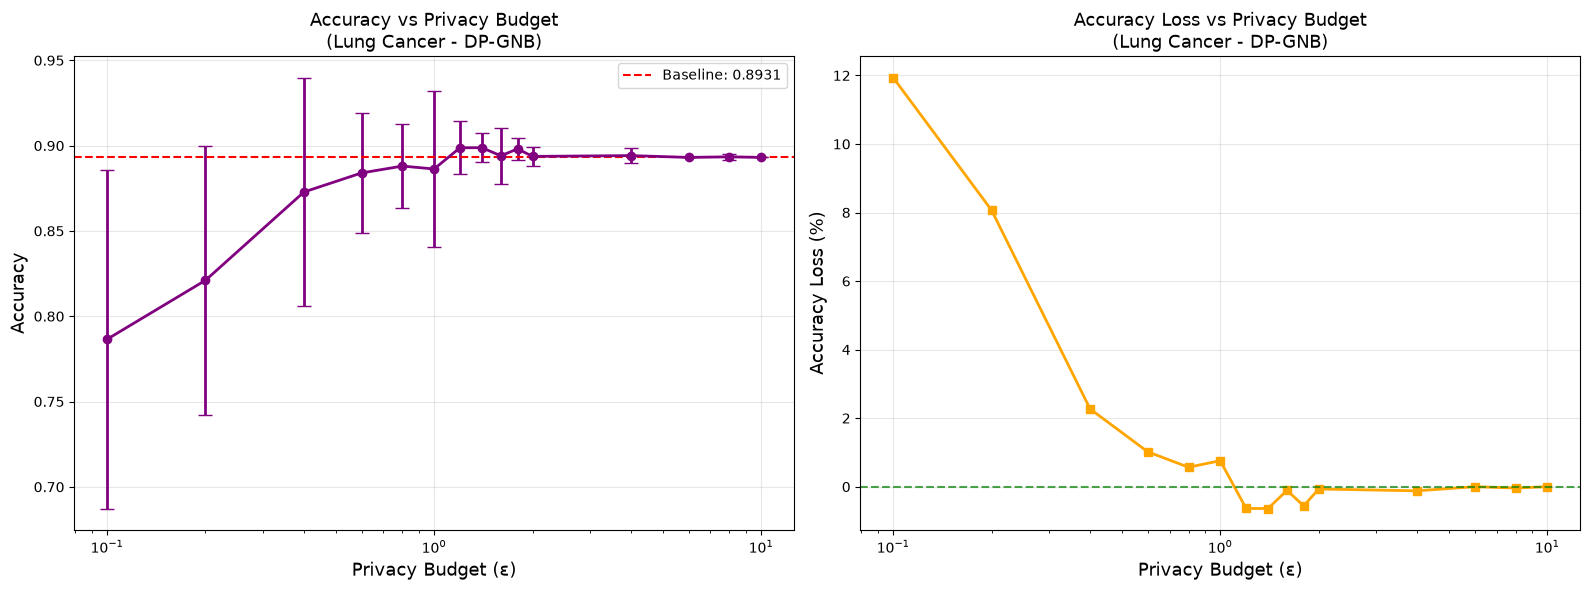

Plot saved to ./output/dp_gnb_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].errorbar(results_df['epsilon'], results_df['accuracy_mean'],
                 yerr=results_df['accuracy_std'], marker='o', capsize=5, linewidth=2, color='purple')
if baseline_accuracy is not None:
    axes[0].axhline(y=baseline_accuracy, color='red', linestyle='--',
                    label=f'Baseline: {baseline_accuracy:.4f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Privacy Budget (ε)', fontsize=13)
axes[0].set_ylabel('Accuracy', fontsize=13)
axes[0].set_title('Accuracy vs Privacy Budget\n(Lung Cancer - DP-GNB)', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
if 'accuracy_loss_pct' in results_df.columns:
    axes[1].plot(results_df['epsilon'], results_df['accuracy_loss_pct'], marker='s', linewidth=2, color='orange')
    axes[1].axhline(y=0, color='green', linestyle='--', alpha=0.7)
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Privacy Budget (ε)', fontsize=13)
    axes[1].set_ylabel('Accuracy Loss (%)', fontsize=13)
    axes[1].set_title('Accuracy Loss vs Privacy Budget\n(Lung Cancer - DP-GNB)', fontsize=13)
    axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./output/dp_gnb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to ./output/dp_gnb_comparison.png')